## 1. Setup and data loading

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
DATA_PATH = Path('Dataset 2 system logs dataset.csv')
OUTPUT_DIR = Path('results/eda')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.is_file():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
assert 'is_attack' in df.columns, "Expected binary target column 'is_attack'."
df['is_attack'] = pd.to_numeric(df['is_attack'], errors='raise').astype(int)
assert set(df['is_attack'].unique()).issubset({0, 1}), "is_attack must be binary (0/1)."

print(f'Loaded {df.shape[0]:,} rows and {df.shape[1]:,} columns')
df.head()

Loaded 100,000 rows and 63 columns


,timestamp,CPU (%),CPU system (%),memory (GB),threads,disk,ops_sda,util_sda (%),available (MB),writeback (MB),...,Network Port Utilization,Disk Write Operations per Second,Network Interface Throughput,CPU Utilization by Core,CPU Load Average,Disk I/O Utilization by Process,Memory Usage by Process,Network Interface Broadcast Packets,Network Interface Multicast Packets,TCP Connection Count by State
0,1653264015,12,8,2,137,sda2,203,87,601,326,...,21.374984,27.442524,773.778802,82.276509,1.302460,0.907449,31.989304,4.342209,75.032005,80.010555
1,1653264465,29,6,5,182,sda2,160,64,599,156,...,41.528810,2.687175,862.055106,3.413034,4.815457,5.595459,46.555521,62.916891,12.973314,60.718622
2,1653264668,10,9,6,246,sda2,397,90,1000,276,...,5.112373,50.676002,296.277126,53.977365,1.945296,17.889892,81.992400,93.262324,1.842360,69.952761
3,1653264352,31,13,8,276,sda1,433,74,350,704,...,95.334200,39.203402,401.590840,246.671971,0.069329,5.262651,99.036962,73.603123,73.362418,252.569617
4,1653264755,21,14,3,113,sda1,359,82,110,123,...,29.856904,86.123367,793.165660,8.777634,1.437517,88.223138,26.520183,29.165669,23.225988,78.667086


## 2. Choose 5–8 key numeric features

In [3]:
def safe_name(value):
    return re.sub(r'[^A-Za-z0-9]+', '_', value).strip('_').lower()

requested_features = [
    'CPU (%)', 'network_bandwidth', 'network_latency',
    'firewall_packets_dropped', 'TCP Connection Count',
    'memory (GB)', 'packet_loss_rate', 'Disk Write Operations per Second',
]
numeric_features = df.select_dtypes(include='number').columns.drop('is_attack', errors='ignore').tolist()
normalized_columns = {safe_name(column): column for column in numeric_features}
key_features = [normalized_columns[safe_name(name)] for name in requested_features
                if safe_name(name) in normalized_columns]
key_features += [column for column in numeric_features if column not in key_features]
key_features = key_features[:8]

print('Selected EDA features:')
key_features

Selected EDA features:


['CPU (%)',
 'network_bandwidth',
 'network_latency',
 'firewall_packets_dropped',
 'TCP Connection Count',
 'memory (GB)',
 'packet_loss_rate',
 'Disk Write Operations per Second']

## 3. Class-separated feature distributions

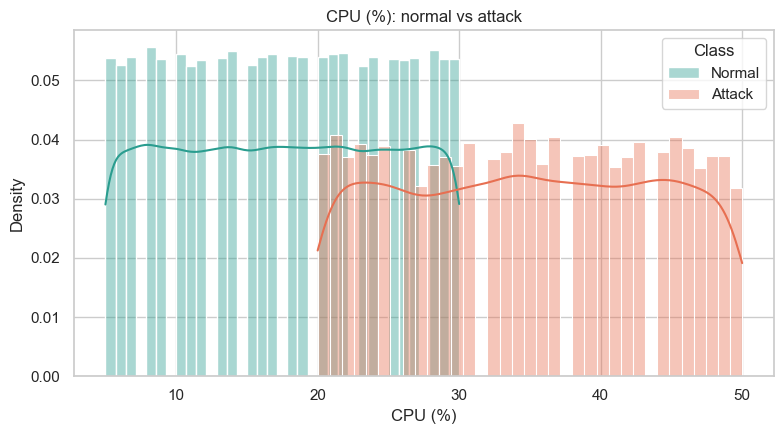

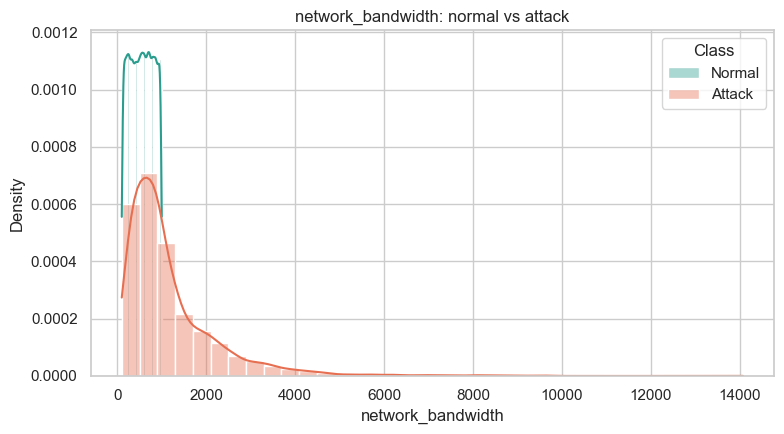

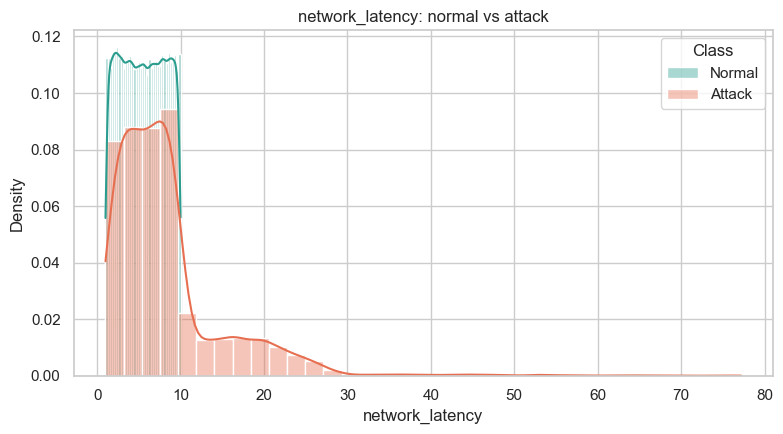

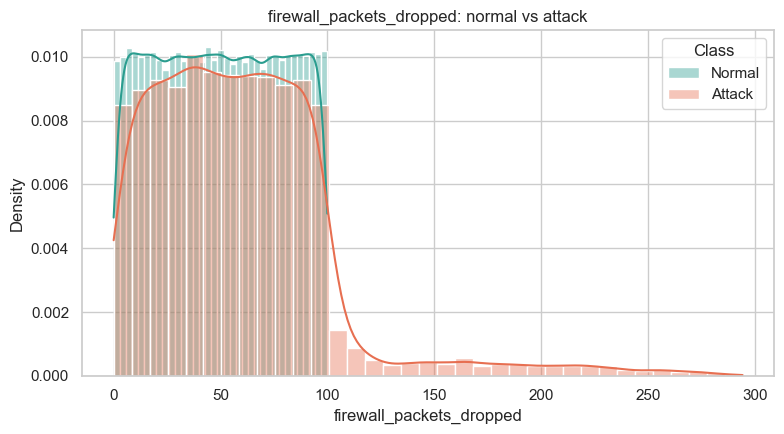

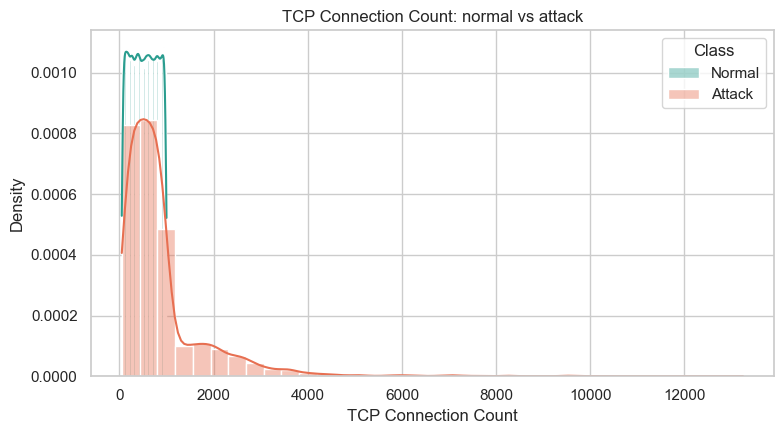

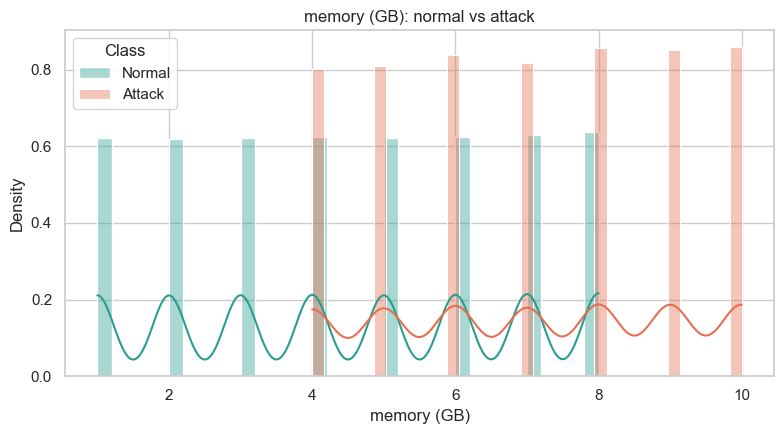

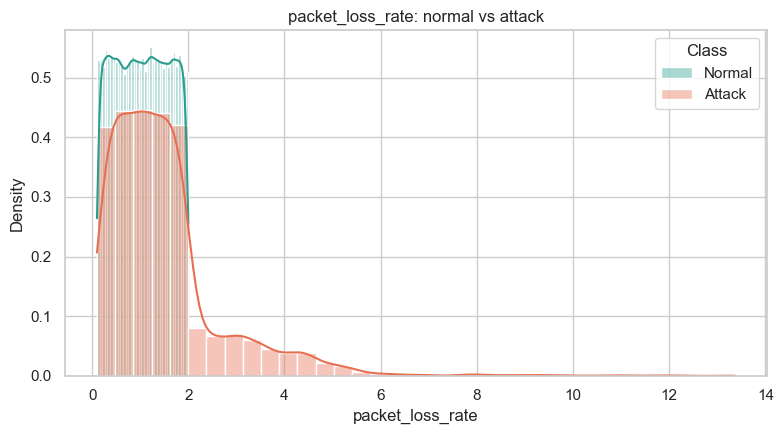

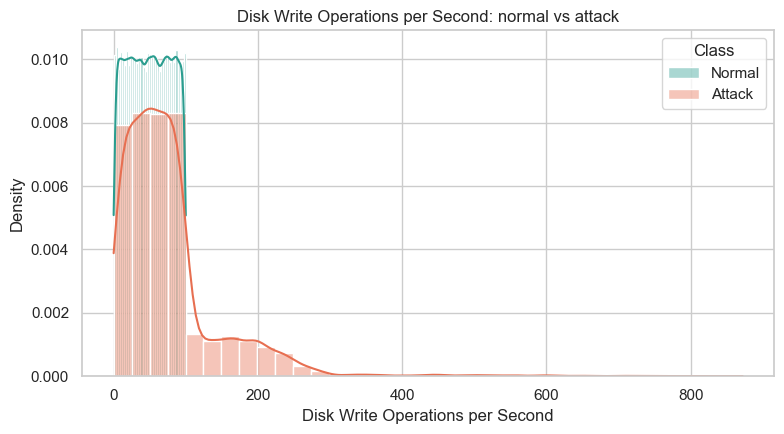

Saved 8 distribution plots to C:\Users\shriy\prp_paper\results\eda


In [4]:
for feature in key_features:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label, class_name, color in [(0, 'Normal', '#2a9d8f'), (1, 'Attack', '#e76f51')]:
        values = df.loc[df['is_attack'] == label, feature].dropna()
        if not values.empty:
            sns.histplot(values, bins=35, stat='density', kde=True, alpha=0.40,
                         color=color, label=class_name, ax=ax)
    ax.set_title(f'{feature}: normal vs attack')
    ax.set_xlabel(feature)
    ax.legend(title='Class')
    fig.tight_layout()
    filename = OUTPUT_DIR / f'distribution_{safe_name(feature)}.png'
    fig.savefig(filename, dpi=220)
    plt.show()
    plt.close(fig)

print(f'Saved {len(key_features)} distribution plots to {OUTPUT_DIR.resolve()}')

## 4. Numeric correlation analysis

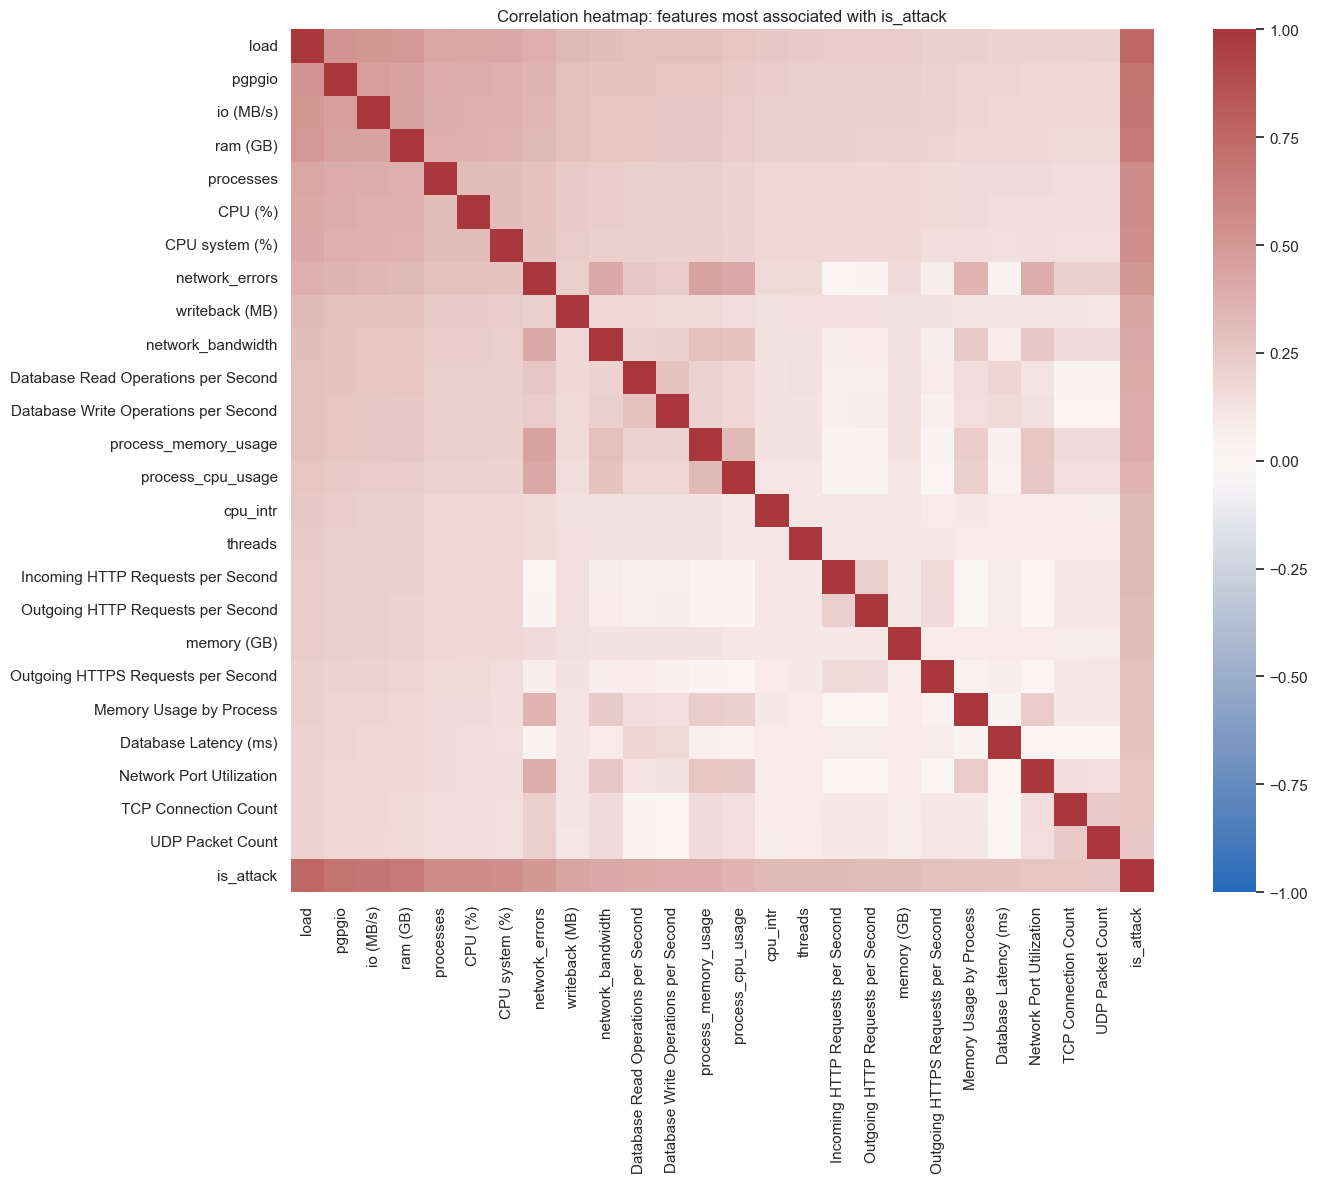

,feature_1,feature_2,correlation


In [5]:
correlation = df[numeric_features + ['is_attack']].corr(numeric_only=True)
correlation.to_csv(OUTPUT_DIR / 'numeric_correlation_matrix.csv')

top_heatmap_features = (correlation['is_attack'].drop('is_attack').abs()
                        .nlargest(min(25, len(numeric_features))).index.tolist())
heatmap_features = top_heatmap_features + ['is_attack']
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(df[heatmap_features].corr(), cmap='vlag', center=0, vmin=-1, vmax=1,
            square=True, ax=ax)
ax.set_title('Correlation heatmap: features most associated with is_attack')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=220)
plt.show()
plt.close(fig)

redundant_pairs = []
for index, left in enumerate(numeric_features):
    for right in numeric_features[index + 1:]:
        r = correlation.loc[left, right]
        if abs(r) >= 0.90:
            redundant_pairs.append((left, right, r))

redundant_df = pd.DataFrame(redundant_pairs, columns=['feature_1', 'feature_2', 'correlation'])
redundant_df.to_csv(OUTPUT_DIR / 'highly_correlated_feature_pairs.csv', index=False)
redundant_df.sort_values('correlation', key=lambda s: s.abs(), ascending=False).head(20)

## 5. Outlier analysis

In [6]:
outlier_rows = []
for feature in numeric_features:
    values = df[feature].dropna()
    if values.empty:
        continue
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    overall_rate = ((values < lower) | (values > upper)).mean()
    class_rates = {}
    for label in [0, 1]:
        class_values = df.loc[df['is_attack'] == label, feature].dropna()
        class_rates[label] = ((class_values < lower) | (class_values > upper)).mean()
    outlier_rows.append([feature, lower, upper, overall_rate, class_rates[0], class_rates[1]])

outlier_df = pd.DataFrame(outlier_rows, columns=[
    'feature', 'lower_iqr_bound', 'upper_iqr_bound', 'outlier_rate',
    'normal_outlier_rate', 'attack_outlier_rate'
]).sort_values('outlier_rate', ascending=False)
outlier_df.to_csv(OUTPUT_DIR / 'iqr_outlier_summary.csv', index=False)
outlier_df.head(15)

,feature,lower_iqr_bound,upper_iqr_bound,outlier_rate,normal_outlier_rate,attack_outlier_rate
7,available (MB),-18297.000000,31167.000000,0.12860,0.128989,0.1251
11,load,-0.615000,3.825000,0.04637,0.000000,0.4637
14,ram (GB),-0.500000,11.500000,0.04553,0.000000,0.4553
22,network_errors,-5.279667,15.741889,0.03720,0.000000,0.3720
41,Database Read Operations per Second,-510.008254,1558.755566,0.02568,0.000000,0.2568
24,process_memory_usage,-3.627118,15.001174,0.02485,0.000000,0.2485
42,Database Write Operations per Second,-253.094072,778.170974,0.02462,0.000000,0.2462
15,network_bandwidth,-362.862147,1503.041299,0.02400,0.000000,0.2400
23,process_cpu_usage,-51.356610,154.620742,0.02204,0.000000,0.2204
10,io (MB/s),-1.000000,7.000000,0.01998,0.000000,0.1998


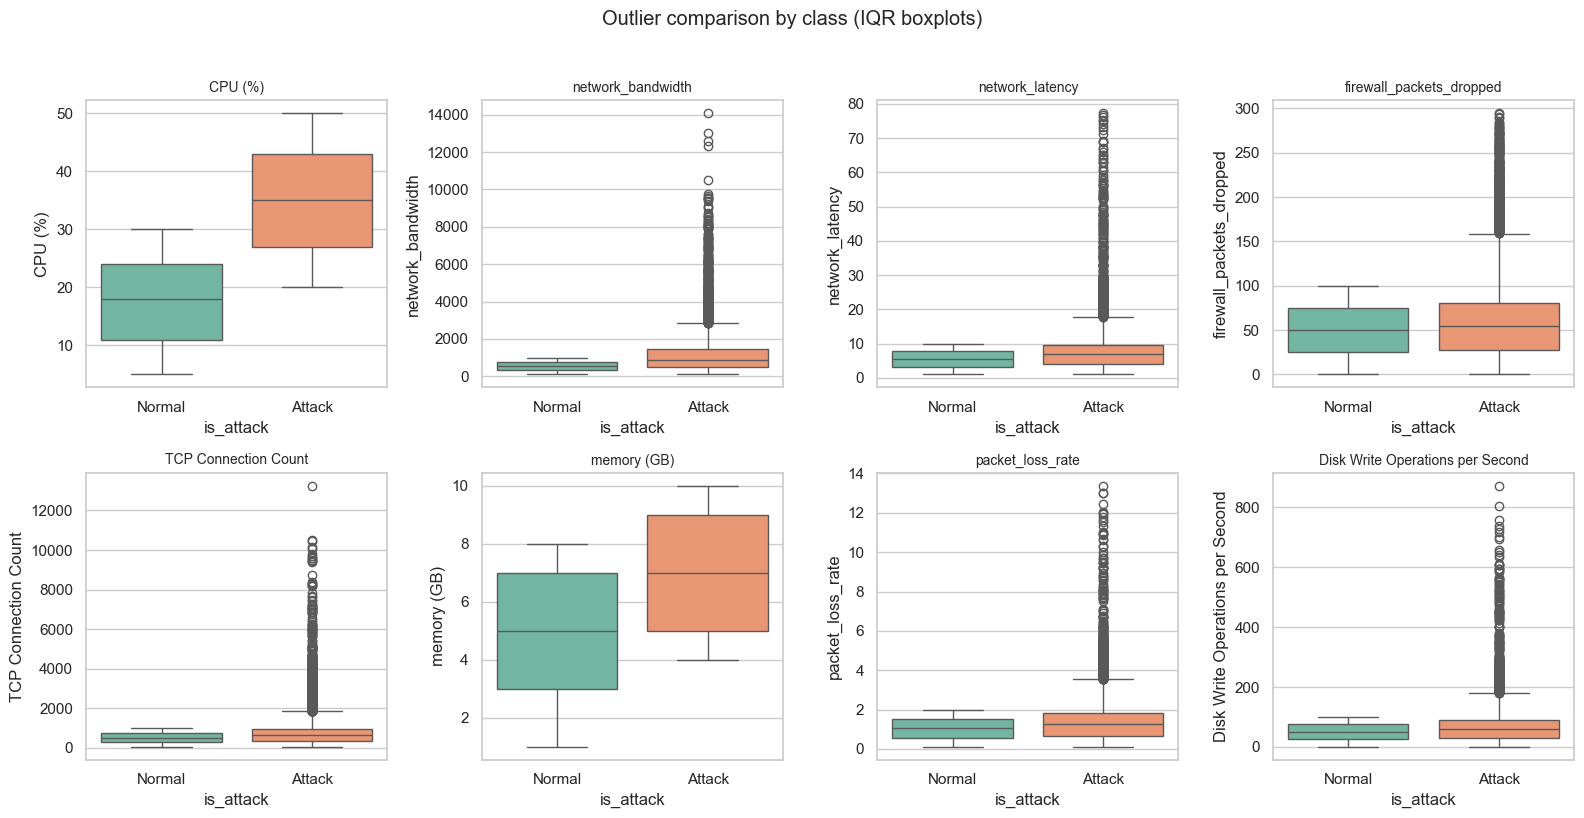

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feature in zip(axes.flat, key_features):
    sns.boxplot(data=df, x='is_attack', y=feature, hue='is_attack',
                palette='Set2', legend=False, ax=ax)
    ax.set_xticks([0, 1], ['Normal', 'Attack'])
    ax.set_title(feature, fontsize=10)
for ax in axes.flat[len(key_features):]:
    ax.axis('off')
fig.suptitle('Outlier comparison by class (IQR boxplots)', y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'outlier_boxplots_by_class.png', dpi=220, bbox_inches='tight')
plt.show()
plt.close(fig)

In [8]:
target_correlation = correlation['is_attack'].drop('is_attack').sort_values(key=np.abs, ascending=False)
medians = df.groupby('is_attack')[target_correlation.index].median().T
medians.columns = ['normal_median', 'attack_median']
feature_summary = pd.DataFrame({
    'abs_correlation_with_is_attack': target_correlation.abs(),
    'correlation_direction': target_correlation,
}).join(medians)
top_features = feature_summary.head(10).round(4)
top_features.to_csv(OUTPUT_DIR / 'top_predictive_features.csv')
top_features

,abs_correlation_with_is_attack,correlation_direction,normal_median,attack_median
load,0.7503,0.7503,1.5000,3.7300
pgpgio,0.6889,0.6889,550.0000,999.0000
io (MB/s),0.6731,0.6731,3.0000,6.0000
ram (GB),0.6568,0.6568,6.0000,11.0000
processes,0.5674,0.5674,250.0000,448.0000
CPU (%),0.5642,0.5642,18.0000,35.0000
CPU system (%),0.5499,0.5499,9.0000,17.0000
network_errors,0.5046,0.5046,4.9929,9.3041
writeback (MB),0.4361,0.4361,299.0000,498.0000
network_bandwidth,0.4085,0.4085,551.3084,867.4557


In [9]:
summary_lines = [
    '# Day 1 EDA — Shriya', '',
    f"- **Dataset:** `{DATA_PATH.name}`",
    f"- **Rows analysed:** {len(df):,}; **columns:** {df.shape[1]:,}",
    f"- **Key features plotted:** {', '.join(key_features)}", '',
    '## Top 10 predictive-feature candidates', '',
    'Ranked by absolute Pearson correlation with the binary target. This is exploratory association, not causal feature importance.', '',
    top_features.to_markdown(), '',
    '## Outlier interpretation', '',
    'IQR outlier rates overall and by class are stored in `iqr_outlier_summary.csv`. A higher attack-class rate can indicate real attack behaviour; these observations should not be removed without a documented domain-based data-quality reason.', '',
    '## Redundancy note', '',
    'Pairs with absolute correlation ≥ 0.90 are listed in `highly_correlated_feature_pairs.csv` for later modelling consideration.', '',
    '## Saved EDA assets', '',
    '- `distribution_*.png`: normal-versus-attack distributions',
    '- `correlation_heatmap.png`: correlations among target-associated numeric features',
    '- `outlier_boxplots_by_class.png`: class-specific boxplots',
]
(OUTPUT_DIR / 'eda_summary.md').write_text('\n'.join(summary_lines), encoding='utf-8')
print(f'Day 1 EDA complete. Files saved to: {OUTPUT_DIR.resolve()}')

Day 1 EDA complete. Files saved to: C:\Users\shriy\prp_paper\results\eda


## Non-linear association with is_attack (Spearman and Mutual Information)

In [10]:
from sklearn.feature_selection import mutual_info_classif

# --- Spearman correlation (monotonic, not just linear) ---
spearman_corr = df[numeric_features + ['is_attack']].corr(method='spearman')['is_attack'].drop('is_attack')
spearman_corr.to_csv(OUTPUT_DIR / 'spearman_correlation_with_is_attack.csv', header=['spearman_correlation'])

# --- Mutual Information (captures any dependency, linear or not) ---
# MI is sensitive to NaNs, so fill with median for this diagnostic only (does not alter df/original data)
mi_input = df[numeric_features].fillna(df[numeric_features].median())
mi_scores = mutual_info_classif(mi_input, df['is_attack'], random_state=42, discrete_features=False)
mutual_info = pd.Series(mi_scores, index=numeric_features, name='mutual_information')
mutual_info.to_csv(OUTPUT_DIR / 'mutual_information_with_is_attack.csv', header=['mutual_information'])

# --- Combine Pearson, Spearman, and MI into one comparison table ---
pearson_abs = correlation['is_attack'].drop('is_attack').abs()
comparison = pd.DataFrame({
    'pearson_abs': pearson_abs,
    'spearman_abs': spearman_corr.abs(),
    'mutual_information': mutual_info,
}).sort_values('mutual_information', ascending=False)

comparison.to_csv(OUTPUT_DIR / 'association_comparison_pearson_spearman_mi.csv')

print('Top 15 features by Mutual Information (compare against Pearson to spot non-linear signals):')
comparison.head(15).round(4)

Top 15 features by Mutual Information (compare against Pearson to spot non-linear signals):


,pearson_abs,spearman_abs,mutual_information
load,0.7503,0.5196,0.3246
pgpgio,0.6889,0.5196,0.3245
io (MB/s),0.6731,0.5053,0.2586
ram (GB),0.6568,0.4563,0.2246
processes,0.5674,0.4609,0.2152
CPU (%),0.5642,0.4413,0.2051
CPU system (%),0.5499,0.4290,0.1949
writeback (MB),0.4361,0.3239,0.1414
network_errors,0.5046,0.2448,0.1165
threads,0.3279,0.2896,0.1111
